In [1]:
import sys
print(sys.executable)

/opt/anaconda3/envs/stock_env/bin/python


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

plt.style.use('fivethirtyeight')
%matplotlib inline

In [3]:
import yfinance as yf
import datetime as dt

stock = "POWERGRID.NS"
start = dt.datetime(2000, 1, 1)
end = dt.datetime(2024, 11, 1)

df = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,
2007-10-05,30.896238,33.629604,25.537000,27.579346,855215656
2007-10-08,29.314569,31.940442,29.130297,31.940442,126671715
2007-10-09,31.310839,31.587245,27.748252,29.329916,116725709
2007-10-10,31.602617,32.247569,31.326210,32.124720,67931378
2007-10-11,35.134487,36.854358,31.326205,36.854358,106320954


In [5]:
df.shape

(4208, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4208 entries, 2007-10-05 to 2024-10-31
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, POWERGRID.NS)   4208 non-null   float64
 1   (High, POWERGRID.NS)    4208 non-null   float64
 2   (Low, POWERGRID.NS)     4208 non-null   float64
 3   (Open, POWERGRID.NS)    4208 non-null   float64
 4   (Volume, POWERGRID.NS)  4208 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 197.2 KB


In [7]:
df.isnull().sum()

Price   Ticker      
Close   POWERGRID.NS    0
High    POWERGRID.NS    0
Low     POWERGRID.NS    0
Open    POWERGRID.NS    0
Volume  POWERGRID.NS    0
dtype: int64

In [8]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
count,4208.000000,4208.000000,4208.000000,4208.000000,4.208000e+03
mean,76.086376,77.075067,75.109494,76.121539,1.188963e+07
std,61.758299,62.480610,60.988901,61.740459,2.061999e+07
min,18.038847,19.282905,16.172760,19.189600,0.000000e+00
25%,34.678073,35.225168,34.165923,34.713574,4.799653e+06
50%,52.692322,53.300716,51.987132,52.793472,8.344398e+06
75%,78.901367,79.843149,77.965749,78.922817,1.362032e+07
max,344.843231,345.598106,337.058427,343.522151,8.552157e+08


In [9]:
df = df.reset_index()

In [10]:
df.columns

MultiIndex([(  'Date',             ''),
            ( 'Close', 'POWERGRID.NS'),
            (  'High', 'POWERGRID.NS'),
            (   'Low', 'POWERGRID.NS'),
            (  'Open', 'POWERGRID.NS'),
            ('Volume', 'POWERGRID.NS')],
           names=['Price', 'Ticker'])

In [11]:
df.to_csv("powergrid.csv")

In [12]:
data01 = pd.read_csv("powergrid.csv")

In [13]:
data01.head()

,Price,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,2007-10-05,30.896238327026367,33.62960397118596,25.53699973003256,27.579346285698307,855215656
2,1,2007-10-08,29.3145694732666,31.940442088112835,29.130296906938245,31.940442088112835,126671715
3,2,2007-10-09,31.31083869934082,31.587245396449305,27.748251921124485,29.32991639984341,116725709
4,3,2007-10-10,31.602617263793945,32.247569316618566,31.326210431319556,32.1247202155724,67931378


In [14]:
# Candlesticks 
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x = data01['Date'], open = data01['Open'], 
                                    high = data01['High'],
                                    low = data01['Low'], 
                                    close = data01['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

In [15]:
df = df.drop(['Date'], axis = 1)

/var/folders/jt/0dc_tb754b7b9j0_m22614y40000gn/T/ipykernel_13614/1002300862.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(['Date'], axis = 1)


In [16]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,30.896238,33.629604,25.537000,27.579346,855215656
1,29.314569,31.940442,29.130297,31.940442,126671715
2,31.310839,31.587245,27.748252,29.329916,116725709
3,31.602617,32.247569,31.326210,32.124720,67931378
4,35.134487,36.854358,31.326205,36.854358,106320954


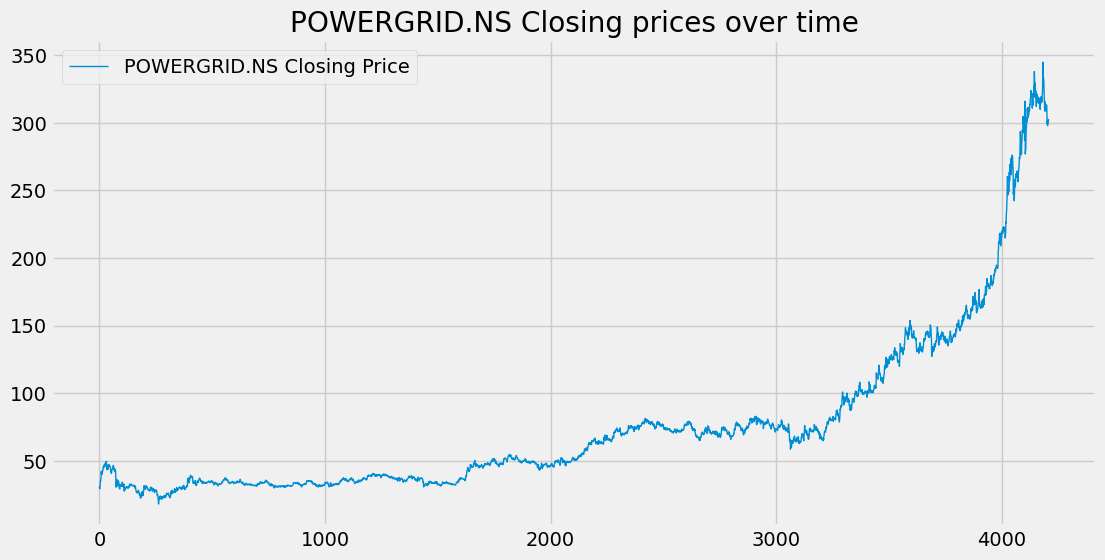

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label = f'{stock} Closing Price', linewidth = 1)
plt.title(f'{stock} Closing prices over time')
plt.legend()
plt.show()

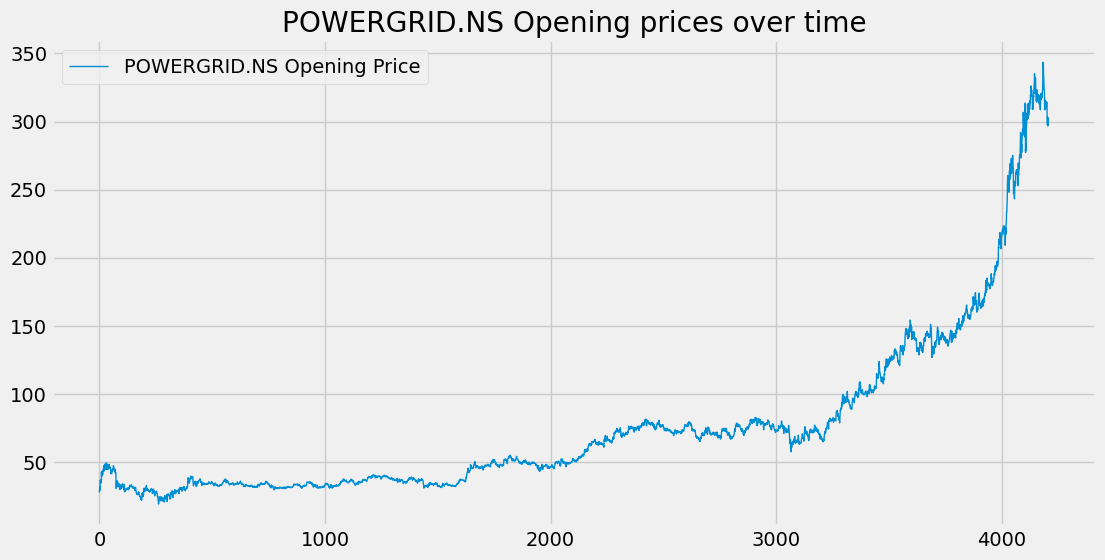

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(df['Open'], label = f'{stock} Opening Price', linewidth = 1)
plt.title(f'{stock} Opening prices over time')
plt.legend()
plt.show()

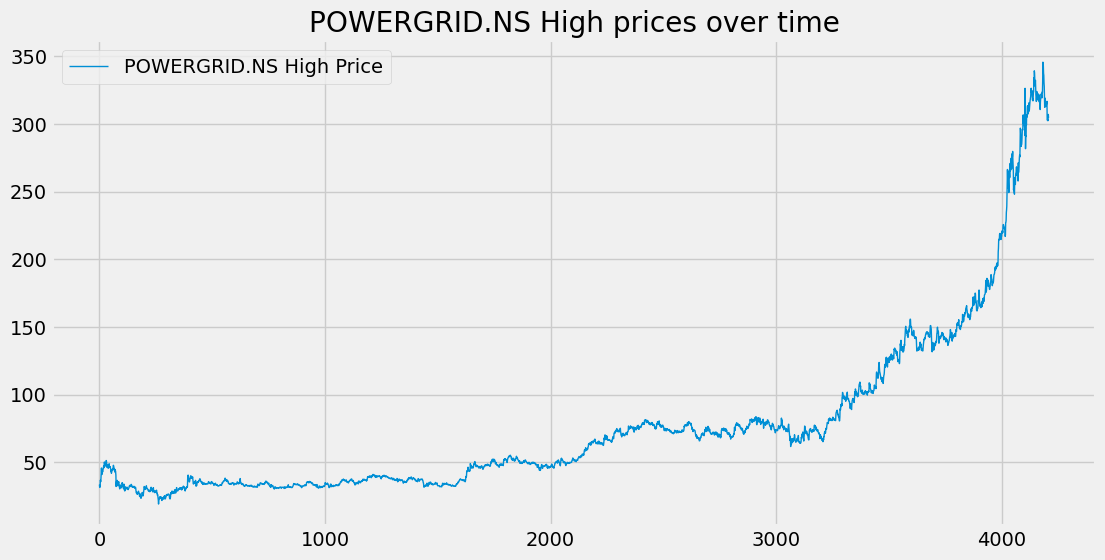

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(df['High'], label = f'{stock} High Price', linewidth = 1)
plt.title(f'{stock} High prices over time')
plt.legend()
plt.show()

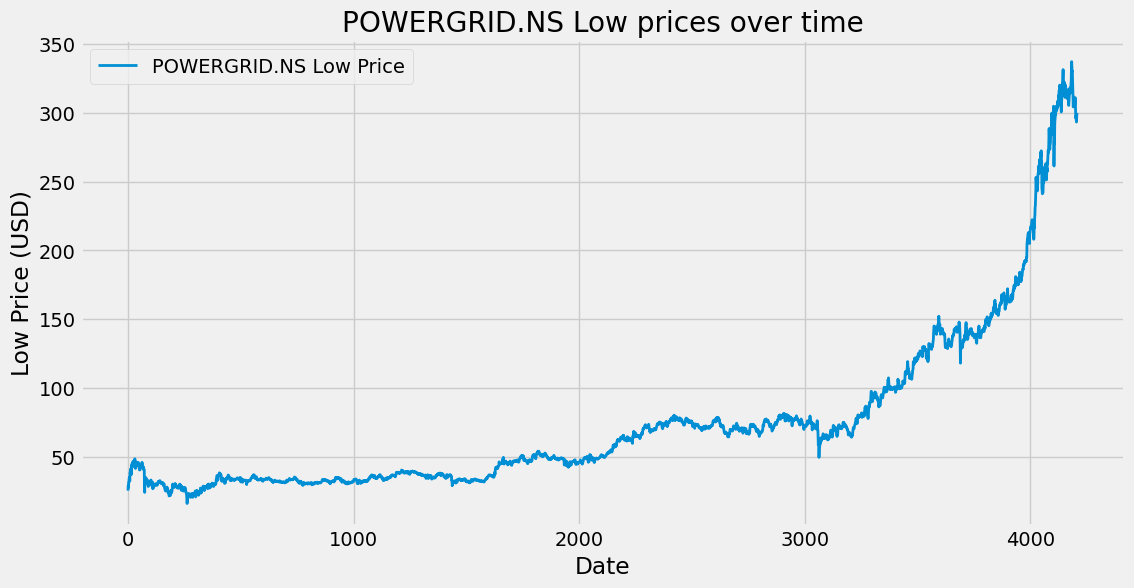

In [20]:
plt.figure(figsize=(12,6))
plt.plot(df['Low'],label=f'{stock} Low Price',linewidth = 2)
plt.title(f'{stock} Low prices over time')
plt.xlabel('Date')
plt.ylabel('Low Price (USD)')
plt.legend()
plt.show()

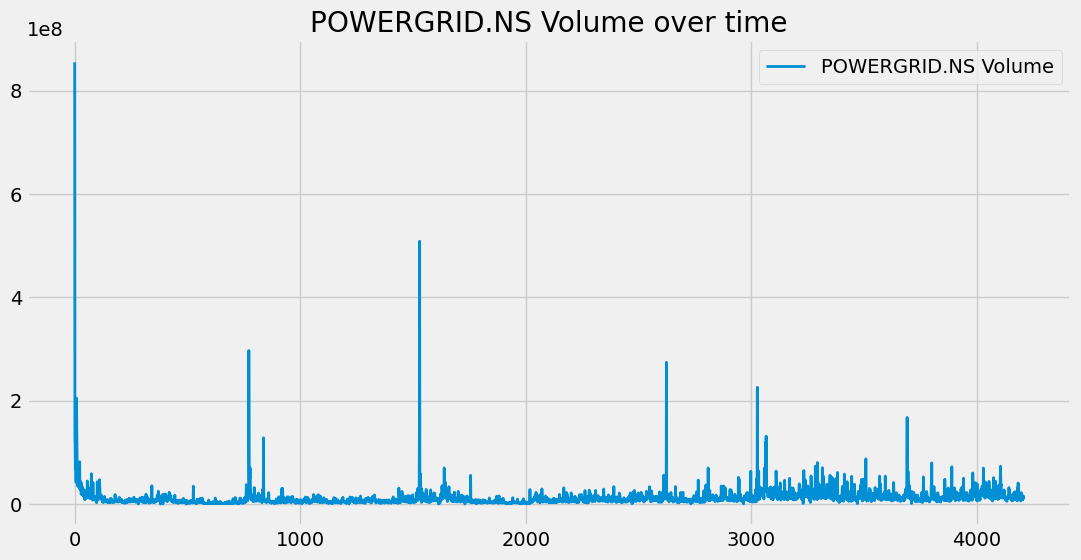

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(df['Volume'], label = f'{stock} Volume', linewidth = 2)
plt.title(f'{stock} Volume over time')
plt.legend()
plt.show()

In [22]:
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90]
print(sum(temp_data[2:7])/5)

50.0


In [23]:
import pandas as pd
df01 = pd.DataFrame(temp_data)

In [24]:
df01.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0


In [25]:
ma100 = df.Close.rolling(100).mean()

In [26]:
ma100

Ticker,POWERGRID.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4203,314.707866
4204,314.941791
4205,315.170277
4206,315.363505


In [27]:
ma200 = df.Close.rolling(200).mean()

In [28]:
ma200 = df.Close.rolling(200).mean()

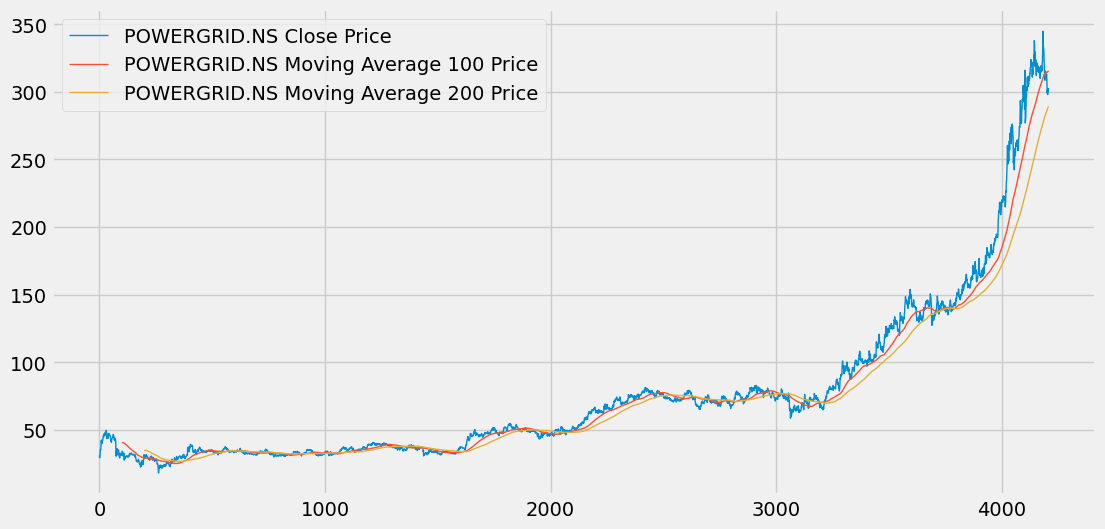

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ma100, label = f'{stock} Moving Average 100 Price', linewidth = 1)
plt.plot(ma200, label = f'{stock} Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [30]:
ema100 = df.Close.ewm(span=100, adjust = False).mean()

In [31]:
ema200 = df['Close'].ewm(span=200, adjust = False).mean()

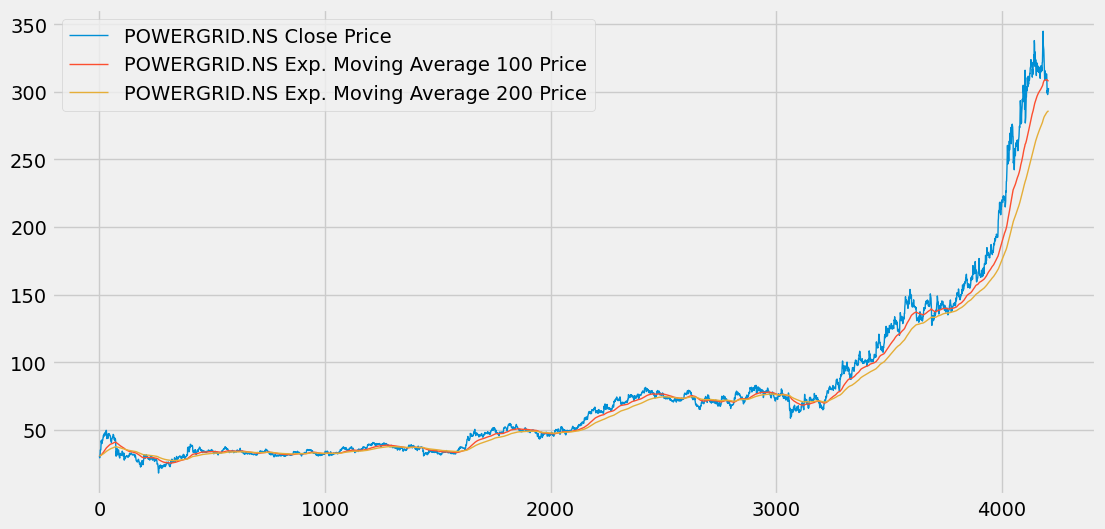

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ema100, label = f'{stock} Exp. Moving Average 100 Price', linewidth = 1)
plt.plot(ema200, label = f'{stock} Exp. Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()


In [33]:
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

In [34]:
data_training.shape

(2945, 1)

In [35]:
data_testing.shape

(1263, 1)

In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range = (0, 1))

In [37]:
data_training_array = scaler.fit_transform(data_training)

In [38]:
data_training_array

array([[0.19808616],
       [0.17371833],
       [0.20447366],
       ...,
       [0.90774424],
       [0.86000392],
       [0.87299661]], shape=(2945, 1))

In [39]:
data_training_array.shape[0]

2945

In [40]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])

x_train, y_train  = np.array(x_train), np.array(y_train)

In [41]:
x_train.shape

(2845, 100, 1)

In [42]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM

print("Keras OK")

Keras OK


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM

model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(60, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(80, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(120))
model.add(Dropout(0.2))

model.add(Dense(1))

# IMPORTANT STEP
model.compile(optimizer='adam', loss='mean_squared_error')

print("Model built successfully")

Model built successfully


/opt/anaconda3/envs/stock_env/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [45]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 117ms/step - loss: 0.0185
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - loss: 0.0026
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - loss: 0.0024
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - loss: 0.0021
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - loss: 0.0022
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - loss: 0.0022
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - loss: 0.0021
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - loss: 0.0019
Epoch 9/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - loss: 0.0018
Epoch 10/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 0.0016
Epoch 11/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - loss: 0.0018
Epoch 12/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 0.0017
Epoch 13/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 0.0017
Epoch 14/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 438s 5s/step - loss: 0.0018
Epoch 15/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 12

In [47]:
past_100_days = data_training.tail(100)

In [49]:
import pandas as pd

final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [50]:
final_df.head()

Ticker,POWERGRID.NS
0,72.249115
1,73.721992
2,73.973930
3,73.818878
4,74.245247


In [51]:
input_data = scaler.fit_transform(final_df)

In [52]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

x_test, y_test  = np.array(x_test), np.array(y_test)

In [53]:
x_test.shape

(1263, 100, 1)

In [54]:
y_predicted = model.predict(x_test)

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step


In [55]:
y_predicted.shape

(1263, 1)

In [56]:
scaler.scale_

array([0.00349382])

In [57]:
scaler_factor = 1 / 0.0035166
y_predicted = y_predicted * scaler_factor
y_test = y_test * scaler_factor

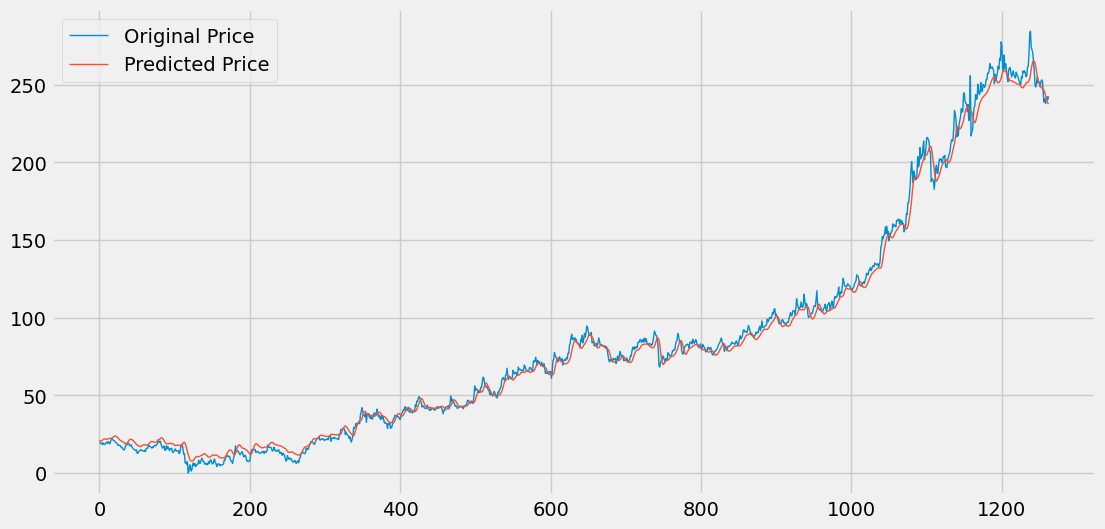

In [58]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label = 'Original Price', linewidth = 1)
plt.plot(y_predicted, label = 'Predicted Price', linewidth = 1)
plt.legend()
plt.show()

In [59]:
model.save('stock_dl_model.h5')

In [62]:
model.save('stock_dl_model.keras')
print('Model saved successfully')

Model saved successfully
